In [2]:
!pip install mplsoccer

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import seaborn as sns
import numpy as np


In [3]:
# 1. Load Data
shotsdf = pd.read_csv("pl_2025_shots.csv")

shotsdf = shotsdf[shotsdf['season'] == 2025]

In [4]:
# Global Preprocessing
shotsdf['X'] = shotsdf['X'].astype(float)
shotsdf['Y'] = shotsdf['Y'].astype(float)
shotsdf['team'] = np.where(shotsdf['h_a'] == 'h', shotsdf['h_team'], shotsdf['a_team'])

# Global Player Aggregation (used across multiple plots)
df_player = shotsdf.groupby(['player', 'team']).agg({
    'xG': 'sum',
    'result': lambda x: (x == 'Goal').sum()
}).reset_index()

df_player.columns = ['player', 'team', 'total_xG', 'actual_goals']
df_player['xg_delta'] = df_player['actual_goals'] - df_player['total_xG']

player_stats = shotsdf.groupby('player').agg({
    'xG': ['sum', 'count', 'mean'],
    'result': lambda x: (x == 'Goal').sum()
}).reset_index()

player_stats.columns = ['player', 'total_xG', 'shot_count', 'avg_xG_per_shot', 'goals']
top_forwards = player_stats.sort_values(by='total_xG', ascending=False).head(10)

print("Top 10 Players by Total xG (Likely Forwards):")
print(top_forwards)

# Shared Function for Pitch Maps
def plot_player_shots(player_name, df):
    player_df = df[df['player'] == player_name]
    pitch = Pitch(pitch_type='opta', pitch_color='#22312b', line_color='#c7d5cc')
    fig, ax = pitch.draw(figsize=(10, 7))
    
    goals = player_df[player_df['result'] == 'Goal']
    non_goals = player_df[player_df['result'] != 'Goal']
    
    pitch.scatter(non_goals.X * 100, non_goals.Y * 100, s=100, 
                  edgecolors='white', c='#ea6969', alpha=0.7, ax=ax, label='No Goal')
    pitch.scatter(goals.X * 100, goals.Y * 100, s=200, 
                  edgecolors='black', c='#2fb380', marker='*', ax=ax, label='Goal')
    
    plt.title(f"Shot Map: {player_name} (Total xG: {player_df.xG.sum():.2f})", color='white', size=16)
    plt.legend()
    plt.show()

Top 10 Players by Total xG (Likely Forwards):
                    player   total_xG  shot_count  avg_xG_per_shot  goals
113         Erling Haaland  23.136934         102         0.226833     22
389                 Thiago  21.046960          70         0.300671     19
212             João Pedro  14.059572          61         0.230485     14
95   Dominic Calvert-Lewin  12.980034          56         0.231786     10
189   Jean-Philippe Mateta  12.959903          55         0.235635      8
150           Hugo Ekitike  11.932188          65         0.183572     11
330          Ollie Watkins  11.483466          57         0.201464      8
23         Antoine Semenyo  11.201725          68         0.164731     15
351           Raúl Jiménez  10.750260          61         0.176234      8
111         Enzo Fernández  10.236897          57         0.179595      8


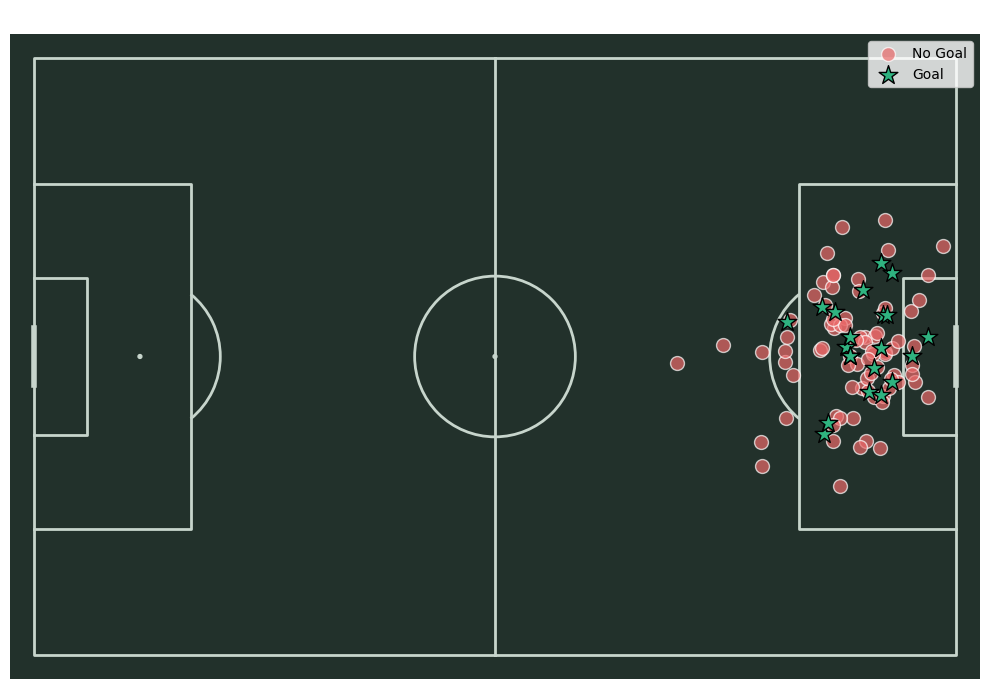

In [5]:
# Visualize the player with the highest xG
top_player = top_forwards.iloc[0]['player']
plot_player_shots(top_player, shotsdf)    

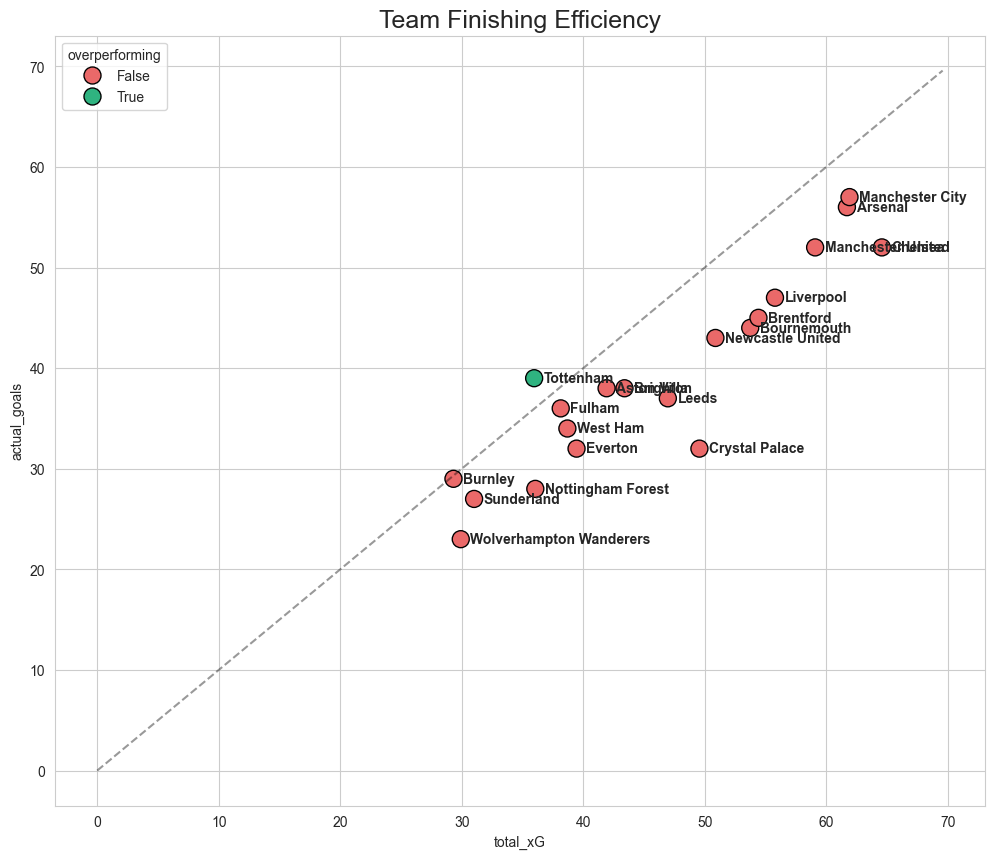

In [6]:
# Aggregate by Team
team_perf = df_player.groupby('team').agg({
    'total_xG': 'sum',
    'actual_goals': 'sum'
}).reset_index()

team_perf['overperforming'] = team_perf['actual_goals'] > team_perf['total_xG']

plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")
sns.scatterplot(data=team_perf, x='total_xG', y='actual_goals', hue='overperforming', 
                palette={True: '#2fb380', False: '#ea6969'}, s=150, edgecolor='black')

# 45-degree line
limit = max(team_perf['total_xG'].max(), team_perf['actual_goals'].max()) + 5
plt.plot([0, limit], [0, limit], color='black', linestyle='--', alpha=0.4)

for i, row in team_perf.iterrows():
    plt.annotate(row['team'], (row['total_xG'], row['actual_goals']), xytext=(7, 0), 
                 textcoords='offset points', fontsize=10, va='center', fontweight='bold')

plt.title("Team Finishing Efficiency", fontsize=18)
plt.show()

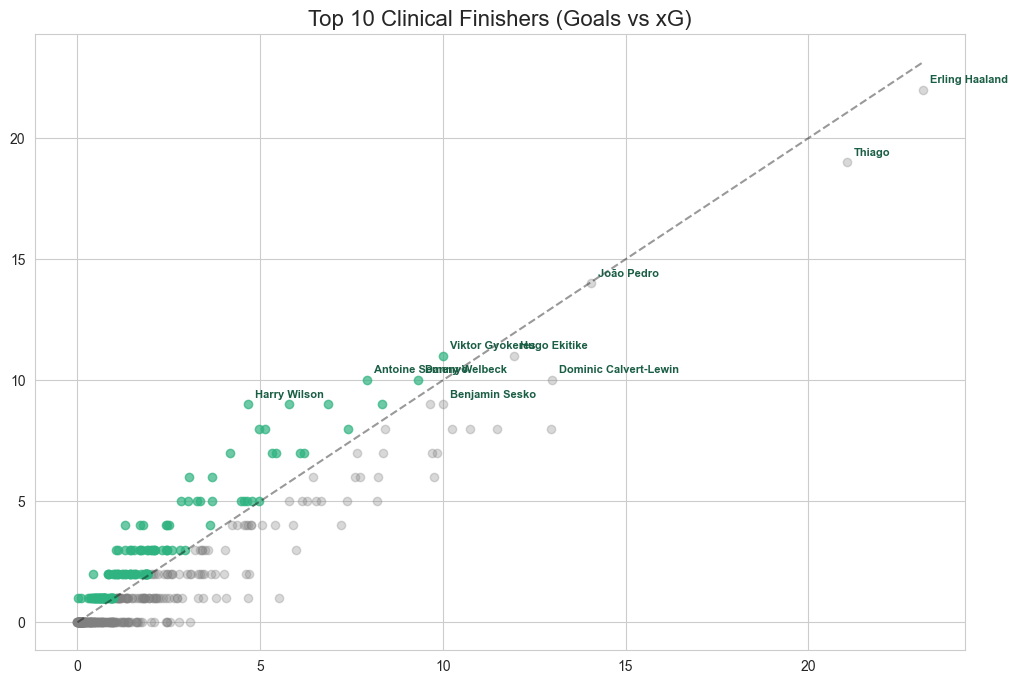

In [7]:
top_finishers = df_player.sort_values(by='actual_goals', ascending=False).head(10)

plt.figure(figsize=(12, 8))
over = df_player[df_player['xg_delta'] > 0]
under = df_player[df_player['xg_delta'] <= 0]

plt.scatter(under['total_xG'], under['actual_goals'], alpha=0.3, color='gray')
plt.scatter(over['total_xG'], over['actual_goals'], alpha=0.7, color='#2fb380')

# Parity line
max_v = df_player[['total_xG', 'actual_goals']].max().max()
plt.plot([0, max_v], [0, max_v], color='black', linestyle='--', alpha=0.4)

for i, row in top_finishers.iterrows():
    plt.annotate(row['player'], (row['total_xG'], row['actual_goals']), xytext=(5, 5), 
                 textcoords='offset points', fontsize=8, fontweight='bold', color='#1a5e45')

plt.title("Top 10 Clinical Finishers (Goals vs xG)", fontsize=16)
plt.show()


Defensive Performance (xG Conceded):
                       team  xG_conceded  shots_faced  goals_conceded
5                   Burnley    66.523170          501              54
18                 West Ham    57.055869          453              53
19  Wolverhampton Wanderers    55.685142          430              50
15        Nottingham Forest    51.946432          378              41
16               Sunderland    48.843244          442              34
1               Aston Villa    47.255291          388              36
9                    Fulham    47.162186          356              40
17                Tottenham    47.026621          390              47
7            Crystal Palace    46.893879          345              34
10                    Leeds    46.177427          366              46
3                 Brentford    46.011357          372              39
8                   Everton    45.993794          411              34
6                   Chelsea    45.391847          32

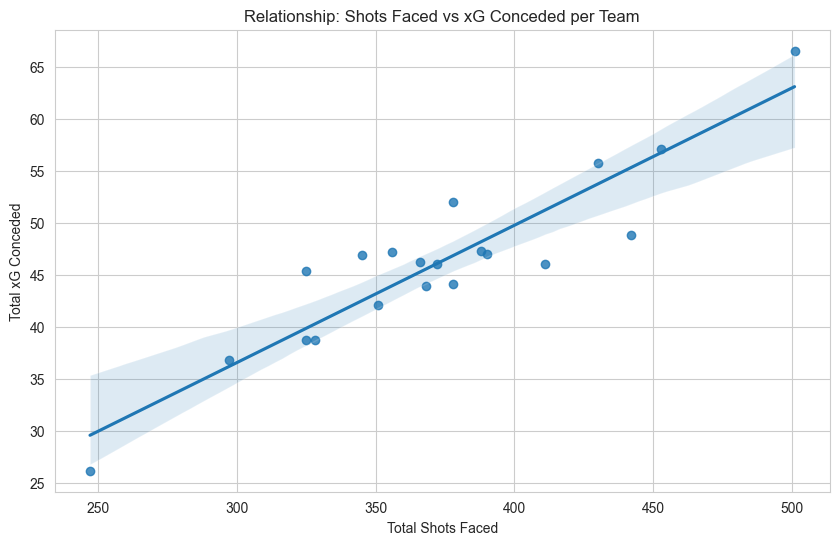


xG Conceded by Situation:
situation       DirectFreekick  FromCorner   OpenPlay   Penalty  SetPiece
defending_team                                                           
Arsenal               0.345943    3.172405  20.076777  0.000000  2.557181
Aston Villa           0.483787    7.971429  34.601158  1.522338  2.676580
Bournemouth           0.579238    8.716299  28.050008  3.044639  3.673775
Brentford             0.377864    4.784751  33.415052  5.328182  2.105508
Brighton              0.434912    5.063713  30.850059  4.567013  3.020842


In [15]:
# ---------------------------------------------------------
# QUESTION 2: Teams/Defenses Conceding xG
# ---------------------------------------------------------

# To find which 'defense' concedes the most, we look at the opponent 
# When h_a == 'h', the shot was taken by the home team, so the away team (a_team) was defending.
shotsdf['defending_team'] = shotsdf.apply(lambda x: x['a_team'] if x['h_a'] == 'h' else x['h_team'], axis=1)

defensive_stats = shotsdf.groupby('defending_team').agg({
    'xG': ['sum', 'count'],
    'result': lambda x: (x == 'Goal').sum()
}).reset_index()

defensive_stats.columns = ['team', 'xG_conceded', 'shots_faced', 'goals_conceded']
defensive_stats = defensive_stats.sort_values(by='xG_conceded', ascending=False)

print("\nDefensive Performance (xG Conceded):")
print(defensive_stats)

# Plotting the relationship between shots faced and xG conceded
plt.figure(figsize=(10,6))
sns.regplot(data=defensive_stats, x='shots_faced', y='xG_conceded')
plt.title("Relationship: Shots Faced vs xG Conceded per Team")
plt.xlabel("Total Shots Faced")
plt.ylabel("Total xG Conceded")
plt.show()

# ---------------------------------------------------------
# QUESTION 3: Relationship with Situations (Proxy for Phase)
# ---------------------------------------------------------

# Since we don't have formation data, we analyze 'situation' (OpenPlay, FromCorner, etc.)
# This helps identify if teams concede more during specific phases.
situation_analysis = shotsdf.groupby(['defending_team', 'situation'])['xG'].sum().unstack().fillna(0)
print("\nxG Conceded by Situation:")
print(situation_analysis.head())


Attacking Performance (xG Generated):
                 team  xG_generated  shots_taken  goals_scored  xG_per_shot
6             Chelsea     64.575106          414            52     0.155979
12    Manchester City     61.908537          442            57     0.140065
0             Arsenal     61.696627          455            56     0.135597
13  Manchester United     59.081919          480            52     0.123087
11          Liverpool     55.777086          470            47     0.118675


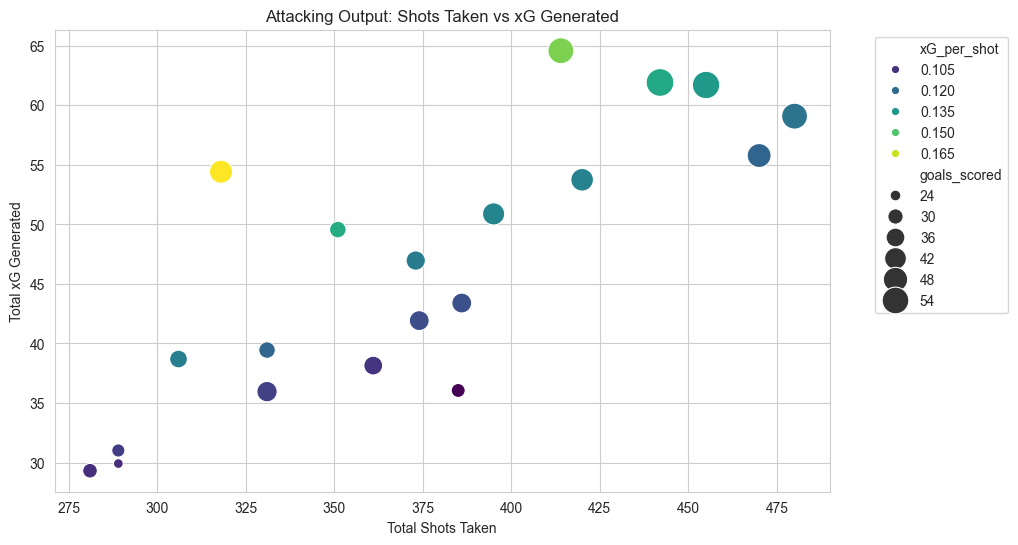


Attacking xG by Situation (Top 5 Creative Teams):
situation          DirectFreekick  FromCorner   OpenPlay   Penalty  SetPiece  \
attacking_team                                                                 
Liverpool                0.812876    6.564099  45.405101  1.522338  1.472672   
Manchester City          0.555734    8.349009  49.052597  3.044675  0.906521   
Nottingham Forest        0.617165    4.776012  27.655614  1.522338  1.483473   
Manchester United        0.482895    6.551853  45.164508  3.805844  3.076819   
Aston Villa              0.966189    6.567049  31.072559  0.000000  3.312683   

situation           total_xG  open_play_pct  
attacking_team                               
Liverpool          55.777086      81.404576  
Manchester City    61.908537      79.233979  
Nottingham Forest  36.054602      76.704810  
Manchester United  59.081919      76.443874  
Aston Villa        41.918480      74.126159  


In [9]:
# ---------------------------------------------------------
# QUESTION 2 (Extended): Teams/Attacks Generating xG
# ---------------------------------------------------------

# Determine which team took the shot
shotsdf['attacking_team'] = shotsdf.apply(lambda x: x['h_team'] if x['h_a'] == 'h' else x['a_team'], axis=1)

attacking_stats = shotsdf.groupby('attacking_team').agg({
    'xG': ['sum', 'count'],
    'result': lambda x: (x == 'Goal').sum()
}).reset_index()

attacking_stats.columns = ['team', 'xG_generated', 'shots_taken', 'goals_scored']

# Calculate quality per shot (xG per Shot)
attacking_stats['xG_per_shot'] = attacking_stats['xG_generated'] / attacking_stats['shots_taken']
attacking_stats = attacking_stats.sort_values(by='xG_generated', ascending=False)

print("\nAttacking Performance (xG Generated):")
print(attacking_stats.head())

# Plotting the relationship between shots taken and xG generated
plt.figure(figsize=(10,6))
sns.scatterplot(data=attacking_stats, x='shots_taken', y='xG_generated', hue='xG_per_shot', size='goals_scored', sizes=(50, 400), palette='viridis')
plt.title("Attacking Output: Shots Taken vs xG Generated")
plt.xlabel("Total Shots Taken")
plt.ylabel("Total xG Generated")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

# ---------------------------------------------------------
# QUESTION 3 (Extended): Attacking Situations
# ---------------------------------------------------------

# Analyze which 'situation' creates the most xG for each team
attack_situation = shotsdf.groupby(['attacking_team', 'situation'])['xG'].sum().unstack().fillna(0)

# Calculate percentage of xG from Open Play to identify 'creative' vs 'set-piece' teams
attack_situation['total_xG'] = attack_situation.sum(axis=1)
attack_situation['open_play_pct'] = (attack_situation['OpenPlay'] / attack_situation['total_xG']) * 100

print("\nAttacking xG by Situation (Top 5 Creative Teams):")
print(attack_situation.sort_values(by='open_play_pct', ascending=False).head())

In [10]:
# Define 'Clutch' conditions: Minute 80+ and score difference <= 1
shotsdf['score_diff'] = abs(shotsdf['h_goals'] - shotsdf['a_goals'])
clutch_df = shotsdf[(shotsdf['minute'] >= 80) & (shotsdf['score_diff'] <= 1)].copy()

clutch_stats = clutch_df.groupby('player').agg({
    'xG': 'sum',
    'result': lambda x: (x == 'Goal').sum()
}).reset_index()

clutch_stats.columns = ['player', 'clutch_xG', 'clutch_goals']
clutch_stats['clutch_delta'] = clutch_stats['clutch_goals'] - clutch_stats['clutch_xG']

# Filter for players with at least 0.5 cumulative clutch xG to avoid small sample noise
top_clutch = clutch_stats[clutch_stats['clutch_xG'] > 0.5].sort_values(by='clutch_delta', ascending=False)

print("Top 5 'Clutch' Finishers (Late Game Overperformers):")
print(top_clutch.head())

Top 5 'Clutch' Finishers (Late Game Overperformers):
                 player  clutch_xG  clutch_goals  clutch_delta
220       Mohamed Salah   1.454233             3      1.545767
259         Richarlison   1.625489             3      1.374511
308       William Osula   0.665667             2      1.334333
134  Jan Paul van Hecke   0.841736             2      1.158264
21       Benjamin Sesko   0.844359             2      1.155641


In [11]:
# Filter out shots with no assisted player (NaN)
supply_line = shotsdf.dropna(subset=['player_assisted'])

# Aggregate xG by Passer -> Shooter pairs
pairs = supply_line.groupby(['player_assisted', 'player']).agg({
    'xG': 'sum',
    'result': lambda x: (x == 'Goal').sum()
}).reset_index()

pairs.columns = ['passer', 'shooter', 'total_xG_created', 'actual_goals']
pairs = pairs.sort_values(by='total_xG_created', ascending=False)

print("\nTop 5 Most Dangerous Partnerships (By xG Created):")
print(pairs.head(5))

# Optional: Find the 'Main Provider' for a specific player (e.g., Gyökeres)
target_player = 'Viktor Gyokeres'
provider = pairs[pairs['shooter'] == target_player].sort_values(by='total_xG_created', ascending=False)

print(f"\nWho feeds {target_player} the best chances?")
print(provider.head(3))


Top 5 Most Dangerous Partnerships (By xG Created):
              passer         shooter  total_xG_created  actual_goals
1812   Mathis Cherki  Erling Haaland          3.628544             2
1480    Kevin Schade          Thiago          2.910977             3
2228      Phil Foden  Erling Haaland          2.665958             1
252   Bernardo Silva  Erling Haaland          2.504374             1
1990   Morgan Rogers   Ollie Watkins          2.456526             2

Who feeds Viktor Gyokeres the best chances?
                  passer          shooter  total_xG_created  actual_goals
374          Bukayo Saka  Viktor Gyokeres          1.318218             0
914   Gabriel Martinelli  Viktor Gyokeres          1.091324             2
1552    Leandro Trossard  Viktor Gyokeres          0.972572             0
